Importing Libraries

In [22]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

Load and inspect the data

In [23]:

df = pd.read_csv('Advertising.csv')
display(df.head(5))
df.shape
df.columns




,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


Index(['Unnamed: 0', 'TV', 'radio', 'newspaper', 'sales'], dtype='str')

Select features and target

In [24]:
df.isna().sum()
df.drop(columns=['Unnamed: 0'], inplace=True)
#display(df.head(5))
X = df[['TV', 'radio', 'newspaper']]
y = df['sales']
X.shape, y.shape

((200, 3), (200,))

Split the data

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape[0], X_test.shape[0])
print(y_train.shape[0], y_test.shape[0])

LRM = LinearRegression()
LRM.fit(X_train, y_train)

print(LRM.intercept_, LRM.coef_ )
print("Intercept:", LRM.intercept_)
for feature, coef_ in zip(X.columns, LRM.coef_):
    print(f"{feature} coef :  { coef_}")


160 40
160 40
2.9790673381226256 [0.04472952 0.18919505 0.00276111]
Intercept: 2.9790673381226256
TV coef :  0.044729517468716326
radio coef :  0.1891950542343766
newspaper coef :  0.0027611143413672056


Make predictions & Evaluate the model

In [26]:
LRM_pred = LRM.predict(X_test)

mar =  mean_absolute_error(y_test, LRM_pred)
mse = mean_squared_error(y_test, LRM_pred)
rmse = root_mean_squared_error(y_test, LRM_pred)
r2 =  r2_score(y_test, LRM_pred) 

print("Mean Absolute Error:", mar)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R Square Score;", r2)






Mean Absolute Error: 1.4607567168117606
Mean Squared Error: 3.174097353976104
Root Mean Squared Error: 1.7815996615334502
R Square Score; 0.899438024100912


Create visualizations

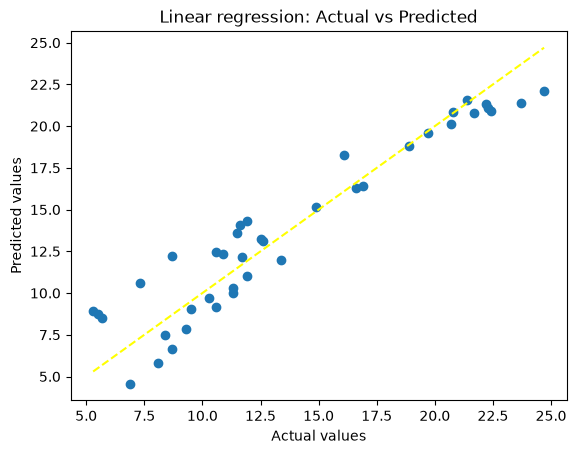

In [27]:
from matplotlib import pyplot as plt
plt.scatter(y_test, LRM_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='yellow', linestyle='--')
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Linear regression: Actual vs Predicted")
plt.show()

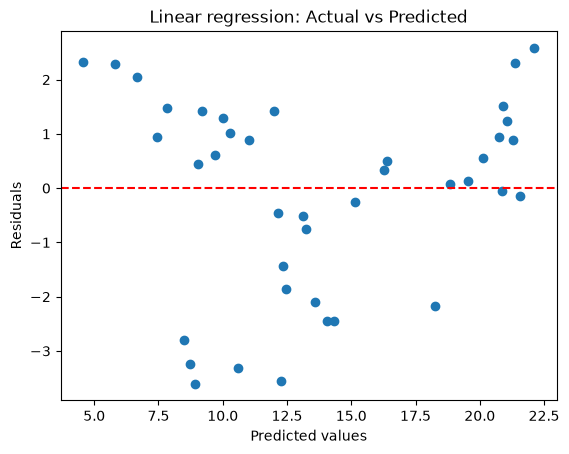

In [28]:
residuals = y_test - LRM_pred
plt.scatter( LRM_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Linear regression: Actual vs Predicted")
plt.show()